# MONAI Ultrasound Working Group - Demo Notebook

Welcome to the demo notebook for the **MONAI Ultrasound Working Group (USWG)**! 
This notebook provides a complete walk-through of a typical medical imaging segmentation workflow. It covers:
1. **Model Loading:** Loading a pre-trained Brain-Segmentation PyTorch UNet model.
2. **Data Retrieval:** Downloading and preprocessing an example medical MRI image.
3. **Inference:** Running model inference to generate predictions.
4. **Data Simulation:** Simulating Ground Truth and Prediction masks to demonstrate metrics tracking.
5. **Metrics Evaluation:** Evaluating the predictions using the `monai_wg.metrics` wrapper.
6. **Error Visualization:** Visualizing the segmentation errors (True Positives, False Positives, False Negatives) using the `monai_wg.plotting` utilities.

Let's get started by importing the necessary libraries.

## 🛠️ Installation & Setup

To use the tools showcased in this notebook, ensure you have the following installed:

```bash
pip install monai matplotlib pandas seaborn scikit-learn scipy torch torchvision pyyaml
```

*Note: This repository also requires standard libraries like `PIL`, `cv2`, and `urllib`.*

## 📂 Project Structure

A quick overview of the repository layout:

```text
.
├── monai_wg/             # Core evaluation package
│   ├── metrics.py        # Segmentation metric wrappers
│   ├── plotting.py       # Scientific visualization tools
│   └── postprocessing.py # Standard post-processing pipelines
├── .../                  # Individual Model(s) Submodule (architectures & weights) Eg. UNet, SAM3, etc
├── config.yaml           # Global experiment configuration
├── demo_notebook.ipynb   # (This file) Complete visual guide
└── benchmark_sam.ipynb   # Large-scale benchmarking script
```

In [1]:
import torch
import urllib
import numpy as np
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import cv2

## 1. Model Loading
We will use a pre-trained Brain-Segmentation PyTorch UNet model from PyTorch Hub for this demonstration. 
This provides a ready-to-use model to generate segmentation predictions for testing.

In [2]:
# Example model taken from "https://pytorch.org/hub/mateuszbuda_brain-segmentation-pytorch_unet/"
model = torch.hub.load('mateuszbuda/brain-segmentation-pytorch', 'unet',
    in_channels=3, out_channels=1, init_features=32, pretrained=True)

Using cache found in C:\Users\tejas/.cache\torch\hub\mateuszbuda_brain-segmentation-pytorch_master


## 2. Data Retrieval
Next, we download an example MRI image that the model will process. We save it locally as `sample_mri.png`.

In [3]:
# Download an example image
url, filename = ("https://github.com/mateuszbuda/brain-segmentation-pytorch/raw/master/assets/TCGA_CS_4944.png", "sample_mri.png")
try: urllib.URLopener().retrieve(url, filename)
except Exception: urllib.request.urlretrieve(url, filename)

Let's load the downloaded image using standard Python Imaging Library (PIL) and display it using Matplotlib.

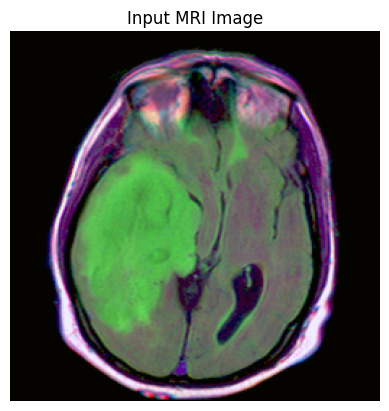

In [4]:
input_image = Image.open(filename)
plt.imshow(input_image)
plt.title('Input MRI Image')
plt.axis('off')
plt.show()

## 3. Preprocessing and Inference
Before passing the image to the model, we need to preprocess it:
- Convert the image to a normalized PyTorch tensor.
- Normalize it using its mean and standard deviation.
- Add a batch dimension using `unsqueeze(0)`.

Once preprocessed, we run it through our UNet model to get the un-thresholded segmentation logits/probabilities.

In [5]:
m, s = np.mean(input_image, axis=(0, 1)), np.std(input_image, axis=(0, 1))
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=m, std=s),
])
input_tensor = preprocess(input_image)
input_batch = input_tensor.unsqueeze(0)

if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    model = model.to('cuda')

with torch.no_grad():
    output = model(input_batch)

print(torch.round(output[0]))

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


Check the shape of our model's output tensor:

In [6]:
print(f"output.shape: {output.shape}")

output.shape: torch.Size([1, 1, 256, 256])


Let's visualize the raw output prediction mask directly from the model.

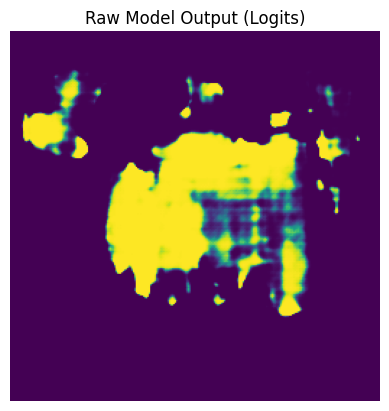

In [7]:
plt.imshow(output[0].permute(1, 2, 0).cpu().numpy())
plt.title('Raw Model Output (Logits)')
plt.axis('off')
plt.show()

## 4. Ground Truth and Prediction Setup
To demonstrate the capabilities of the `monai_wg` tracking and metrics library, we need both a Ground Truth (`y_true`) and a Prediction (`y_pred`).
Because we don't have a real Ground Truth for this sample image, we will simulate them:
- `y_true` will be created by thresholding the model's output at 0.5.
- `y_pred` will be created by thresholding the model's output at 0.2 and applying some morphological erosion. This introduces deliberate discrepancies (errors) between the prediction and the ground truth to test our evaluation functions.

We then plot them side by side for a visual comparison.

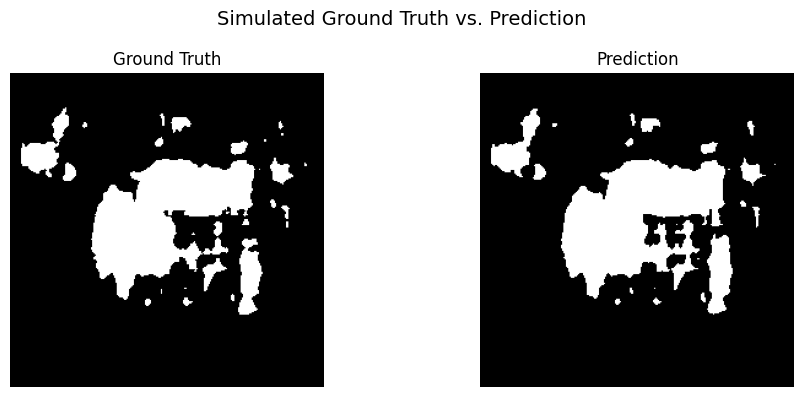

In [8]:
# Using UNet model output to visualize the results
dummy = output.cpu().numpy()
y_true = dummy > 0.5  # Ground truth: threshold at 0.5
y_pred = dummy > 0.2  # Prediction: threshold at 0.2

# Morphological erosion to create realistic discrepancies between y_true and y_pred for visualization purposes
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
y_pred = cv2.erode(y_pred[0].astype('uint8'), kernel=kernel).astype('float')
y_pred = np.expand_dims(y_pred, axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Simulated Ground Truth vs. Prediction', fontsize=14)
ax1.imshow(y_true[0, 0], cmap='gray'); ax1.set_title('Ground Truth'); ax1.axis('off')
ax2.imshow(y_pred[0, 0], cmap='gray'); ax2.set_title('Prediction'); ax2.axis('off')
plt.tight_layout()
plt.show()

## 5. Metrics Evaluation with MONAI USWG
The `monai_wg.metrics.MonaiMetricWrapper` simplifies the process of computing standard segmentation metrics (like Dice, Hausdorff Distance, etc.).

Below, we initialize the wrapper for a single-class segmentation (excluding background) and compute the typical metrics, focusing here on the Dice score.

In [9]:
from monai_wg.metrics import MonaiMetricWrapper

# Initialize
wrapper = MonaiMetricWrapper(num_classes=1, include_background=False)

# Update with prediction and ground truth (B, C, H, W)
wrapper.update(y_pred, y_true)

# Compute Results
results = wrapper.compute()
print(f"Dice: {results['Dice']:.4f}")

Dice: 0.2885


f:\Miniconda\envs\monai\Lib\site-packages\monai\utils\deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


We can also configure the wrapper to compute the metrics for two classes (including the background class) by simply changing the initialization parameters.

In [10]:
from monai_wg.metrics import MonaiMetricWrapper

# Initialize
wrapper = MonaiMetricWrapper(num_classes=2, include_background=True)

# Update with prediction and ground truth (B, C, H, W)
wrapper.update(y_pred, y_true)

# Compute Results
results = wrapper.compute()
print(f"Dice: {results['Dice']:.4f}")

Dice: 0.9684


## 6. Error Heatmap Visualization
Finally, understanding where the model fails is crucial. The `monai_wg.plotting.plot_segmentation_error_heatmap` utility makes it easy to visualize True Positives, False Positives (over-segmentation), and False Negatives (under-segmentation) overlaid directly on the original input image.

This plotting functionality is essential for quickly identifying systematic errors in segmentation models.
- **Red:** False Positives (Model predicted a segment but there wasn't one)
- **Blue:** False Negatives (Model missed a segment)
- **Green/Neutral:** True Positives (Model correctly identified the segment)

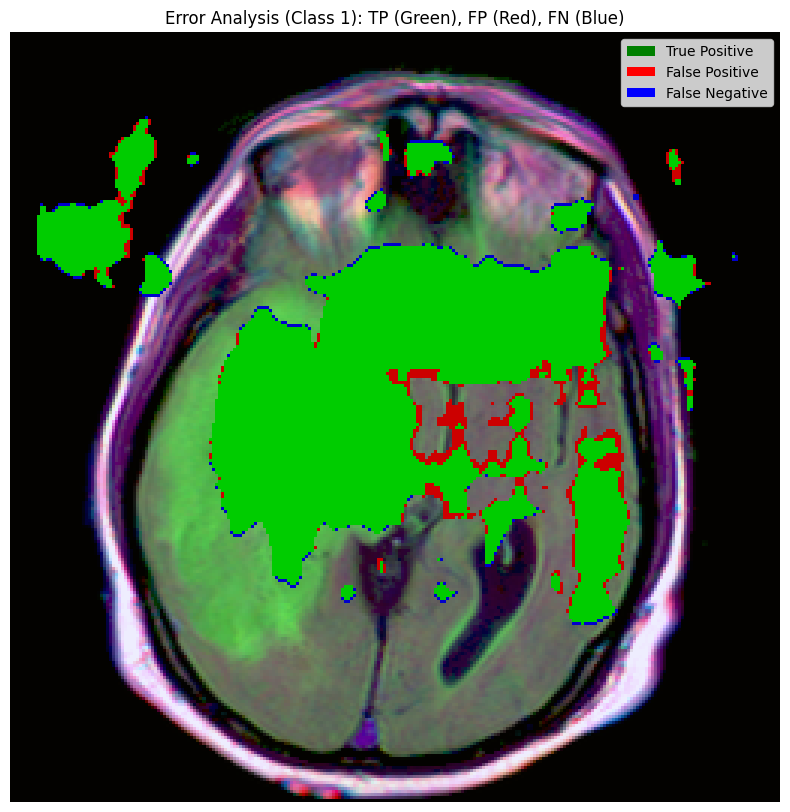

In [11]:
from monai_wg.plotting import plot_segmentation_error_heatmap

plot_segmentation_error_heatmap(image=np.array(input_image), label=y_true[0], pred=y_pred[0])

---
# Part 2: Comprehensive `monai_wg` API Reference

The sections above showed a quick end-to-end workflow.  
Below is a **detailed, self-contained reference** for every metric, plotting function, and post-processing utility in the `monai_wg` package.  
Each sub-section can be run independently using synthetic data.

## 7. All Available Metrics at a Glance

The `MonaiMetricWrapper` computes **six** metrics in a single call:

| Metric | Type | Range | Ideal | Description |
|--------|------|-------|-------|-------------|
| **Dice** | Overlap | 0 → 1 | 1 | Harmonic mean of Precision & Recall (F1) |
| **IoU** (Jaccard) | Overlap | 0 → 1 | 1 | Intersection / Union |
| **HD95** | Distance | 0 → ∞ | 0 | 95th-percentile Hausdorff Distance (px) |
| **ASD** | Distance | 0 → ∞ | 0 | Average Surface Distance (px) |
| **Precision** | Classification | 0 → 1 | 1 | TP / (TP + FP) |
| **Recall** | Classification | 0 → 1 | 1 | TP / (TP + FN) |

Let's create some **synthetic data** so every example below is self-contained.

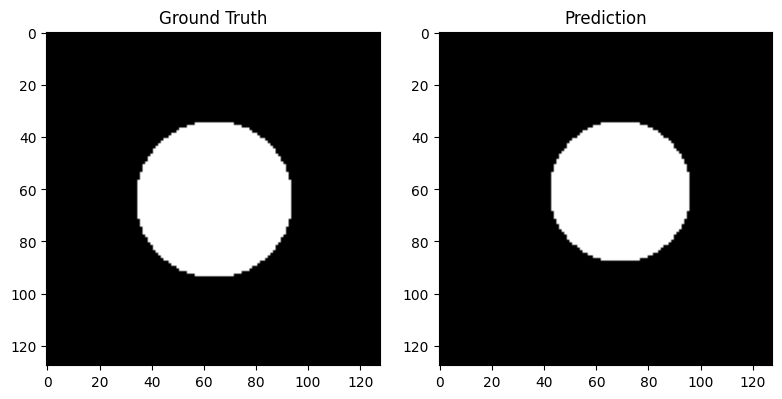

y_true shape: (1, 1, 128, 128)  |  y_pred shape: (1, 1, 128, 128)


In [12]:
import torch, numpy as np, matplotlib.pyplot as plt
from monai_wg.metrics import MonaiMetricWrapper

# ── Create synthetic binary masks (batch=1, channels=1, 128×128) ──
np.random.seed(42)
H, W = 128, 128

# Ground truth: a centered circle
yy, xx = np.mgrid[:H, :W]
gt_circle = ((xx - W//2)**2 + (yy - H//2)**2) < 30**2
y_true_synth = gt_circle.astype(np.float32)[np.newaxis, np.newaxis, ...]   # (1,1,H,W)

# Prediction: a slightly shifted & slightly smaller circle (simulates typical errors)
pred_circle = ((xx - W//2 - 5)**2 + (yy - H//2 + 3)**2) < 27**2
y_pred_synth = pred_circle.astype(np.float32)[np.newaxis, np.newaxis, ...]  # (1,1,H,W)

# Quick visual
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(y_true_synth[0, 0], cmap='gray'); axes[0].set_title('Ground Truth')
axes[1].imshow(y_pred_synth[0, 0], cmap='gray'); axes[1].set_title('Prediction')
plt.tight_layout(); plt.show()
print(f'y_true shape: {y_true_synth.shape}  |  y_pred shape: {y_pred_synth.shape}')

### 7.1 Dice Score (F1)

The **Dice coefficient** measures the overlap between prediction and ground truth.  
It is the harmonic mean of Precision and Recall, equivalent to the F1 score.

$$\text{Dice} = \frac{2 \cdot |P \cap G|}{|P| + |G|}$$

- A Dice of **1.0** means perfect overlap.
- A Dice of **0.0** means no overlap at all.
- It is the most popular metric in medical image segmentation challenges.

In [13]:
wrapper = MonaiMetricWrapper(num_classes=1, include_background=False)
wrapper.update(y_pred_synth, y_true_synth)
results = wrapper.compute()
print(f"Dice Score: {results['Dice']:.4f}")

Dice Score: 0.2927


### 7.2 IoU / Jaccard Index

**Intersection over Union** divides the intersection of prediction and ground truth by their union.

$$\text{IoU} = \frac{|P \cap G|}{|P \cup G|}$$

- More conservative than Dice (IoU ≤ Dice for the same pair).
- Commonly used in detection benchmarks (COCO, Pascal VOC).

In [14]:
wrapper = MonaiMetricWrapper(num_classes=1, include_background=False)
wrapper.update(y_pred_synth, y_true_synth)
results = wrapper.compute()
print(f"IoU (Jaccard): {results['IoU']:.4f}")

IoU (Jaccard): 0.1714


### 7.3 Hausdorff Distance (HD95)

The **95th-percentile Hausdorff Distance** measures the maximum surface-to-surface distance between the boundaries of `y_pred` and `y_true`, at the 95th percentile to reduce sensitivity to outliers.

$$\text{HD}_{95}(P, G) = \text{percentile}_{95}\Big(\max\big(d(P \to G),\, d(G \to P)\big)\Big)$$

- Measured in **pixels**. Lower is better (0 = perfect boundary match).
- Sensitive to boundary accuracy — useful for surgical planning applications.
- The percentile can be changed via the `percentile` parameter of `MonaiMetricWrapper`.

In [15]:
wrapper = MonaiMetricWrapper(num_classes=1, include_background=False, percentile=95)
wrapper.update(y_pred_synth, y_true_synth)
results = wrapper.compute()
print(f"HD95: {results['HD95']:.4f} pixels")

HD95: 57.9828 pixels


### 7.4 Average Surface Distance (ASD)

The **Average Surface Distance** computes the mean distance from every surface point of one mask to the nearest surface point of the other mask, averaged over both directions.

$$\text{ASD} = \frac{1}{|S_P| + |S_G|}\Big(\sum_{p \in S_P} d(p, S_G) + \sum_{g \in S_G} d(g, S_P)\Big)$$

- Also measured in **pixels**. Lower is better (0 = boundaries coincide).
- Less sensitive to outliers than Hausdorff Distance.
- Preferred when you want a smooth, aggregate boundary error.

In [16]:
wrapper = MonaiMetricWrapper(num_classes=1, include_background=False)
wrapper.update(y_pred_synth, y_true_synth)
results = wrapper.compute()
print(f"ASD: {results['ASD']:.4f} pixels")

ASD: 43.1797 pixels


### 7.5 Precision & Recall

**Precision** tells you what fraction of predicted positives are actually positive (low FP is good).  
**Recall** (Sensitivity) tells you what fraction of actual positives were correctly found (low FN is good).

$$\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN}$$

- Both range from **0** to **1** (higher is better).
- Precision penalizes over-segmentation (false positives).
- Recall penalizes under-segmentation (false negatives).

In [17]:
wrapper = MonaiMetricWrapper(num_classes=1, include_background=False)
wrapper.update(y_pred_synth, y_true_synth)
results = wrapper.compute()
print(f"Precision: {results['Precision']:.4f}")
print(f"Recall:    {results['Recall']:.4f}")

Precision: 0.1714
Recall:    1.0000


### 7.6 Computing All Metrics at Once

You don't need to create separate wrappers! A single `MonaiMetricWrapper` computes **all six** metrics in one go.  
Use `get_results_df()` to get a nicely formatted Pandas DataFrame — perfect for logging, CSV export, or display in papers.

In [18]:
wrapper = MonaiMetricWrapper(num_classes=1, include_background=False)
wrapper.update(y_pred_synth, y_true_synth)

# Dictionary of all metrics
all_results = wrapper.compute()
print('All metrics (dict):')
for k, v in all_results.items():
    print(f'  {k:>12s}: {v:.4f}')

# As a Pandas DataFrame
print('\nAs DataFrame:')
df = wrapper.get_results_df()
display(df)

All metrics (dict):
          Dice: 0.2927
           IoU: 0.1714
          HD95: 57.9828
           ASD: 43.1797
     Precision: 0.1714
        Recall: 1.0000

As DataFrame:


,Dice,IoU,HD95,ASD,Precision,Recall
0,0.292711,0.171448,57.982758,43.179676,0.171448,1.0


### 7.7 Effect of `include_background`

By default, background (class 0) is **excluded** from metrics.  
Set `include_background=True` to include it — this often **boosts** scores since background usually dominates the image and is easy to classify correctly.

In [19]:
# Without background
w1 = MonaiMetricWrapper(num_classes=2, include_background=False)
w1.update(y_pred_synth, y_true_synth)
r1 = w1.compute()

# With background
w2 = MonaiMetricWrapper(num_classes=2, include_background=True)
w2.update(y_pred_synth, y_true_synth)
r2 = w2.compute()

print(f"Without background → Dice: {r1['Dice']:.4f}  IoU: {r1['IoU']:.4f}")
print(f"With    background → Dice: {r2['Dice']:.4f}  IoU: {r2['IoU']:.4f}")

Without background → Dice: 0.8536  IoU: 0.7445
With    background → Dice: 0.9133  IoU: 0.8460


f:\Miniconda\envs\monai\Lib\site-packages\monai\utils\deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


---
## 8. Plotting Utilities Reference

The `monai_wg.plotting` module provides **10+** publication-ready visualization functions.  
Below is a working example for each.

### 8.1 `plot_segmentation` — Overlay GT & Prediction on an Image

Overlays Ground Truth (green) and Prediction (red/yellow) contours on the original image.

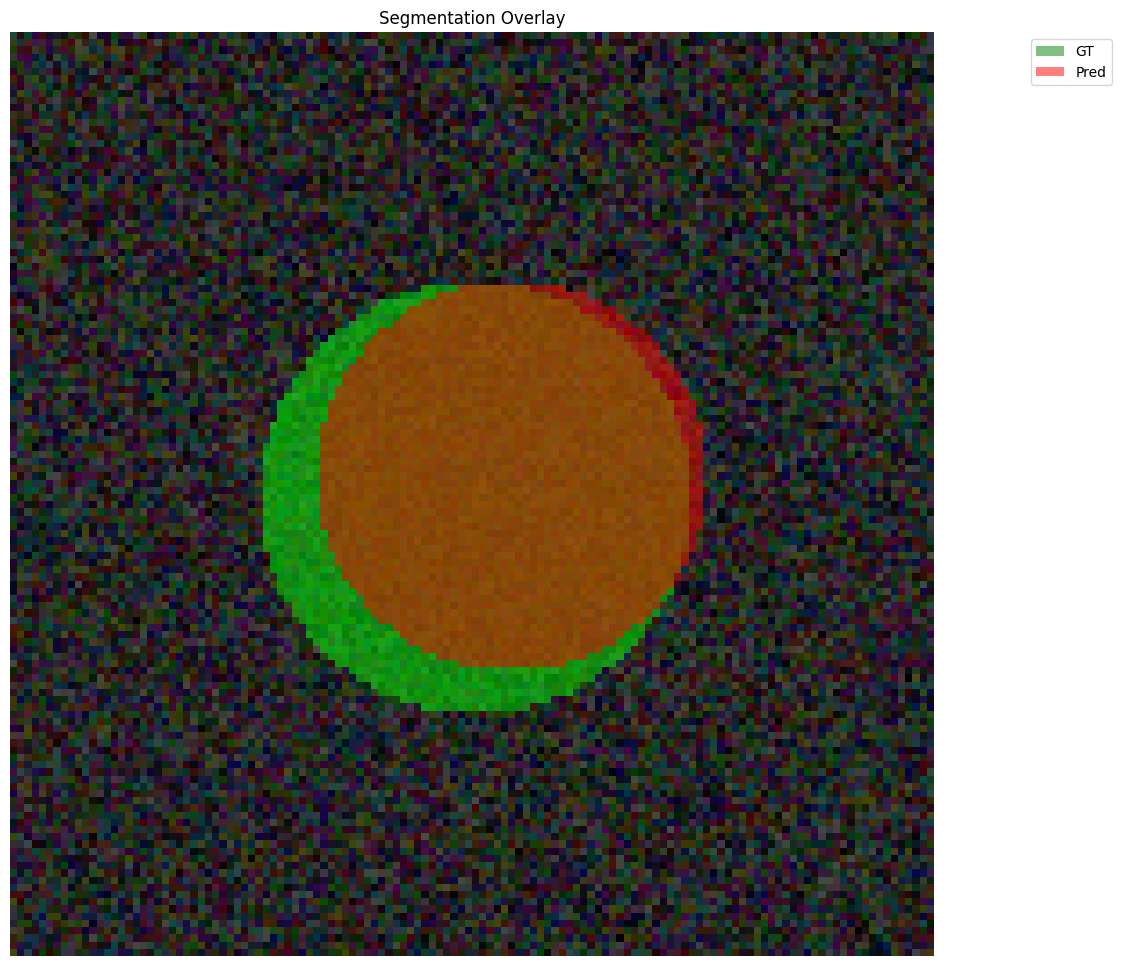

In [20]:
from monai_wg.plotting import plot_segmentation

# Create a dummy grayscale image
dummy_img = np.random.rand(128, 128, 3).astype(np.float32) * 0.3
plot_segmentation(image=dummy_img, label=y_true_synth[0], pred=y_pred_synth[0])

### 8.2 `plot_segmentation_error_heatmap` — TP / FP / FN Visualization

Shows True Positives (green), False Positives (red), and False Negatives (blue) overlaid on the image. Extremely useful for debugging model failures.

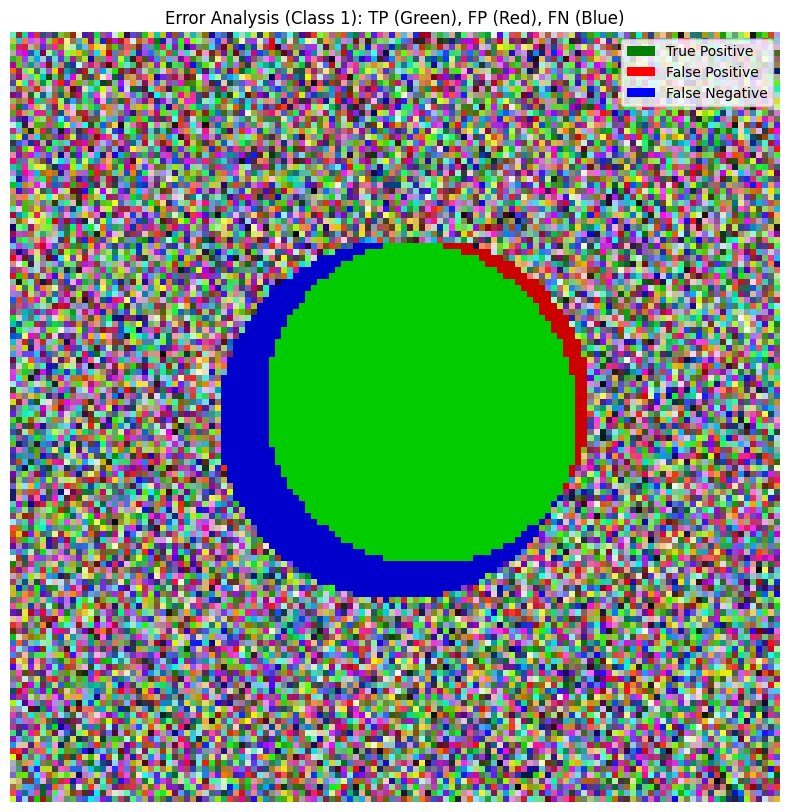

In [21]:
from monai_wg.plotting import plot_segmentation_error_heatmap

plot_segmentation_error_heatmap(
    image=dummy_img, label=y_true_synth[0], pred=y_pred_synth[0]
)

### 8.3 `plot_boundary_comparison` — Boundary Overlap

Extracts the boundaries of both masks and overlays them to show where the predicted contour deviates from the ground truth.

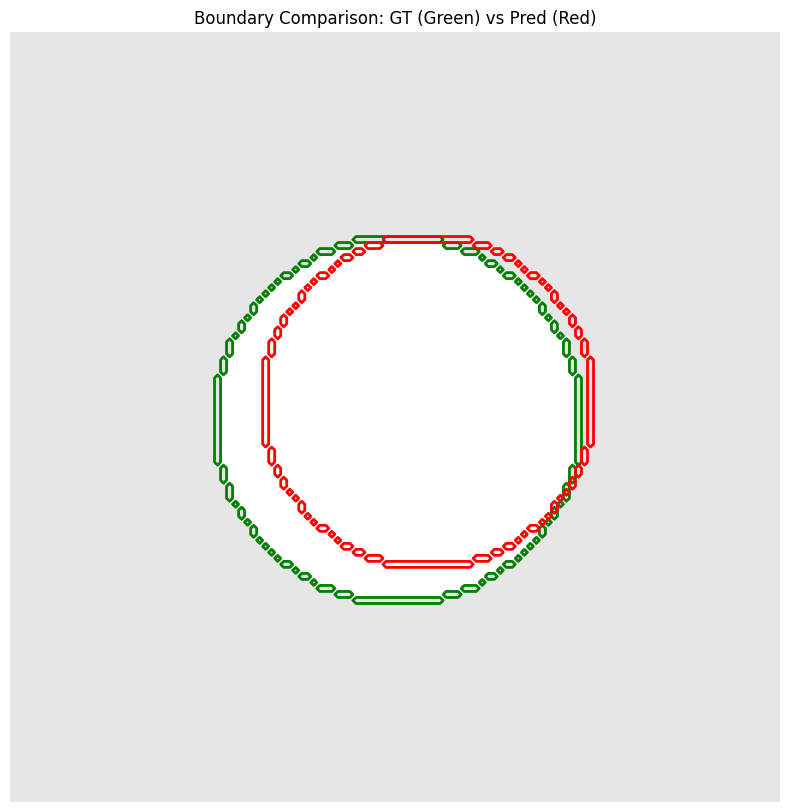

In [22]:
from monai_wg.plotting import plot_boundary_comparison

plot_boundary_comparison(label=y_true_synth[0], pred=y_pred_synth[0])

### 8.4 `plot_pixel_confusion_matrix` — Pixel-level Confusion Matrix

A confusion matrix computed on every pixel, showing how many pixels were classified as TP, TN, FP, FN.

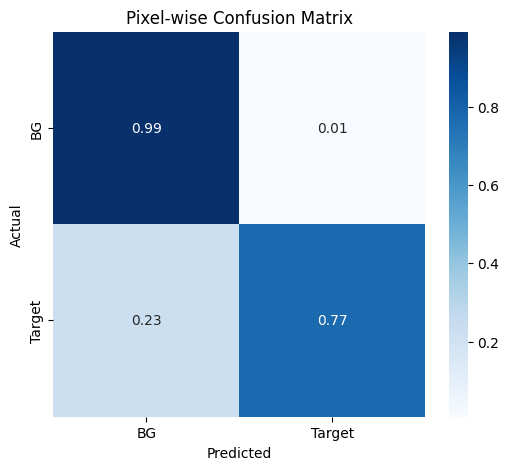

In [23]:
from monai_wg.plotting import plot_pixel_confusion_matrix

plot_pixel_confusion_matrix(
    y_true=y_true_synth[0, 0],
    y_pred=y_pred_synth[0, 0],
    labels=[0, 1] #['Background', 'Foreground']
)

### 8.5 `plot_metric_distribution` — Violin Plots over Multiple Samples

Visualizes the distribution of metrics across a dataset. This requires a `pd.DataFrame` with one row per sample.

f:\AI_ML_Notebooks\Monai-Ultra-Sound-WG\monai_wg\plotting.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=melted_df, x='Metric', y='Score', inner='box', palette="muted")


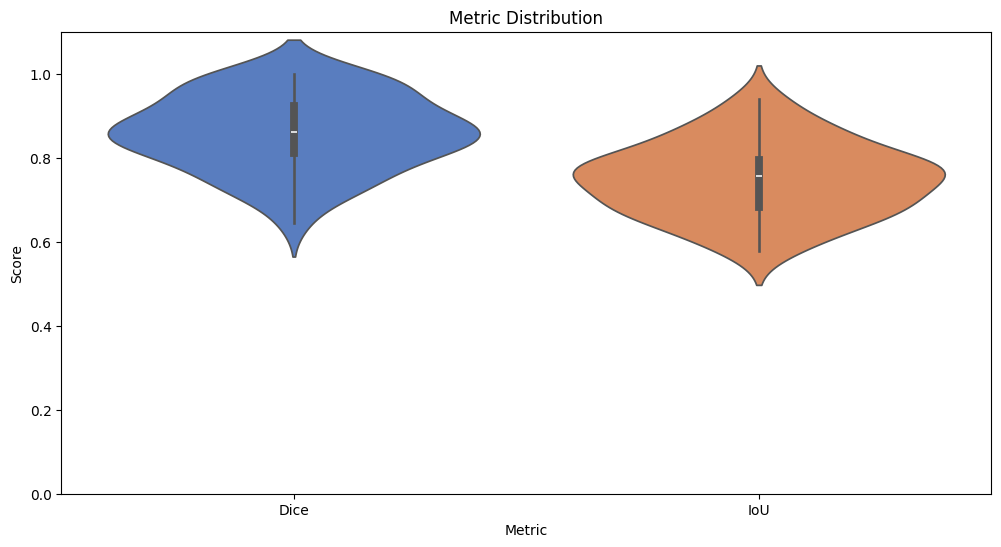

In [24]:
import pandas as pd
from monai_wg.plotting import plot_metric_distribution

# Simulate 50 samples with varying quality
np.random.seed(0)
sim_df = pd.DataFrame({
    'Dice':  np.clip(np.random.normal(0.85, 0.08, 50), 0, 1),
    'IoU':   np.clip(np.random.normal(0.75, 0.10, 50), 0, 1),
    'HD95':  np.abs(np.random.normal(5, 3, 50)),
})

plot_metric_distribution(sim_df, metric_names=['Dice', 'IoU'])

### 8.6 `plot_metric_correlation` — Scatter Plot between Two Metrics

Shows the relationship between two metrics (e.g., Dice vs HD95) with a regression line. Useful for understanding if improvements in one metric track the other.

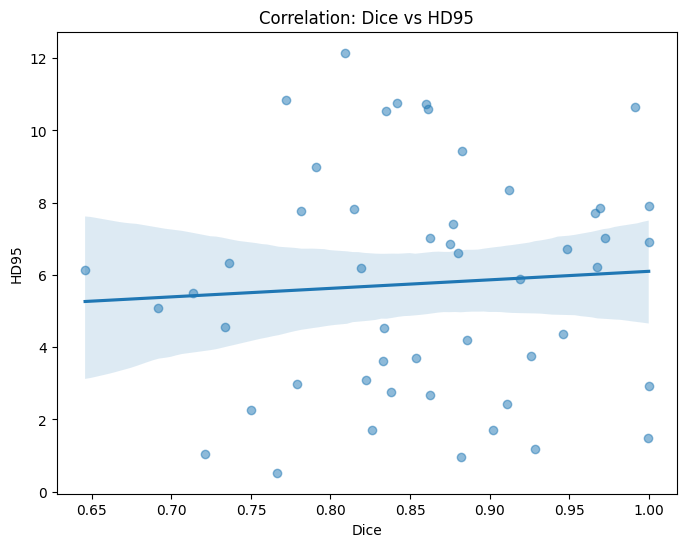

In [25]:
from monai_wg.plotting import plot_metric_correlation

plot_metric_correlation(sim_df, x_metric='Dice', y_metric='HD95')

### 8.7 `plot_dice_cdf` — Cumulative Distribution Function

Shows what percentage of cases exceed a given Dice threshold. Common in challenge leaderboards to show robustness.

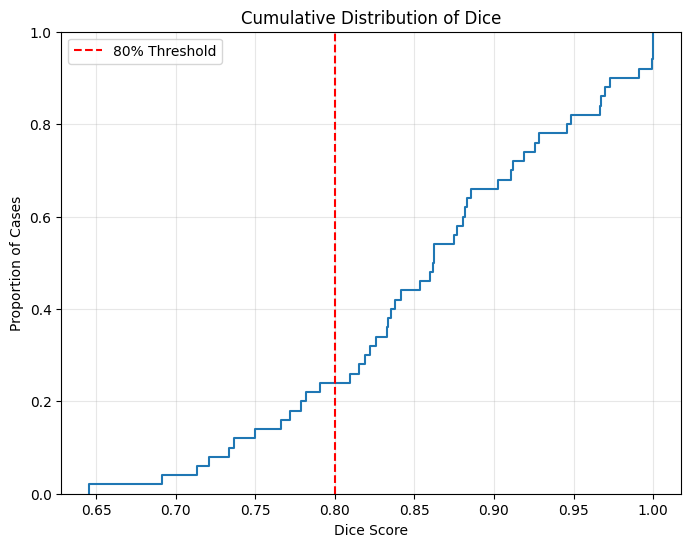

In [26]:
from monai_wg.plotting import plot_dice_cdf

plot_dice_cdf(sim_df, metric_name='Dice')

### 8.8 `plot_model_comparison` — Grouped Bar Chart

Compares multiple models across several metrics in a single grouped bar chart.

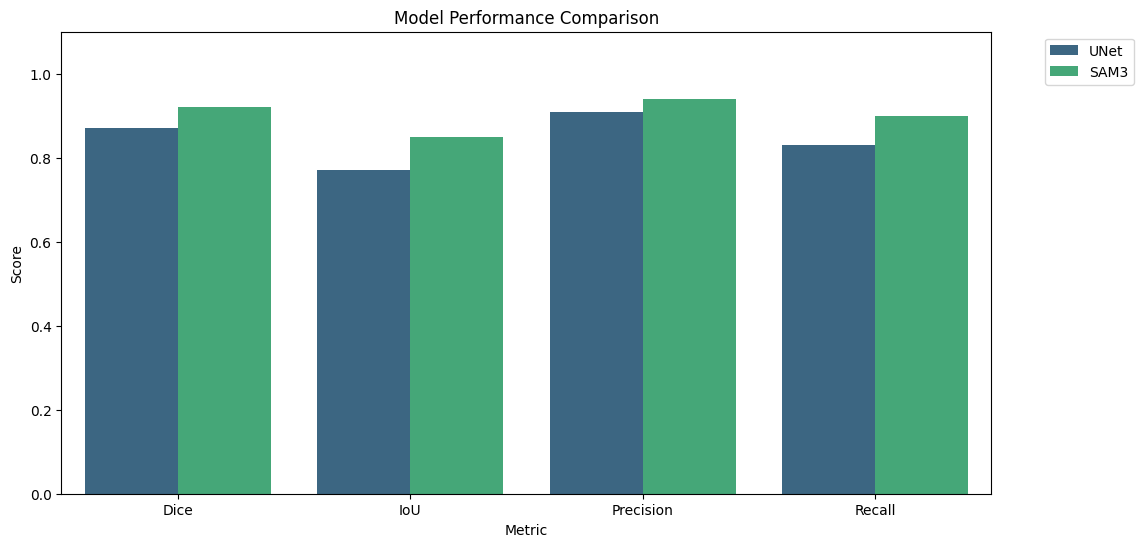

In [27]:
from monai_wg.plotting import plot_model_comparison

comp_df = pd.DataFrame([
    {'Model': 'UNet',  'Metric': 'Dice', 'Score': 0.87},
    {'Model': 'UNet',  'Metric': 'IoU',  'Score': 0.77},
    {'Model': 'UNet',  'Metric': 'Precision', 'Score': 0.91},
    {'Model': 'UNet',  'Metric': 'Recall', 'Score': 0.83},
    {'Model': 'SAM3',  'Metric': 'Dice', 'Score': 0.92},
    {'Model': 'SAM3',  'Metric': 'IoU',  'Score': 0.85},
    {'Model': 'SAM3',  'Metric': 'Precision', 'Score': 0.94},
    {'Model': 'SAM3',  'Metric': 'Recall', 'Score': 0.90},
])

plot_model_comparison(comp_df, metrics=['Dice', 'IoU', 'Precision', 'Recall'])

### 8.9 `plot_radar_chart` — Spider / Radar Chart

A radar chart comparing models across multiple metrics — very common in SOTA papers.

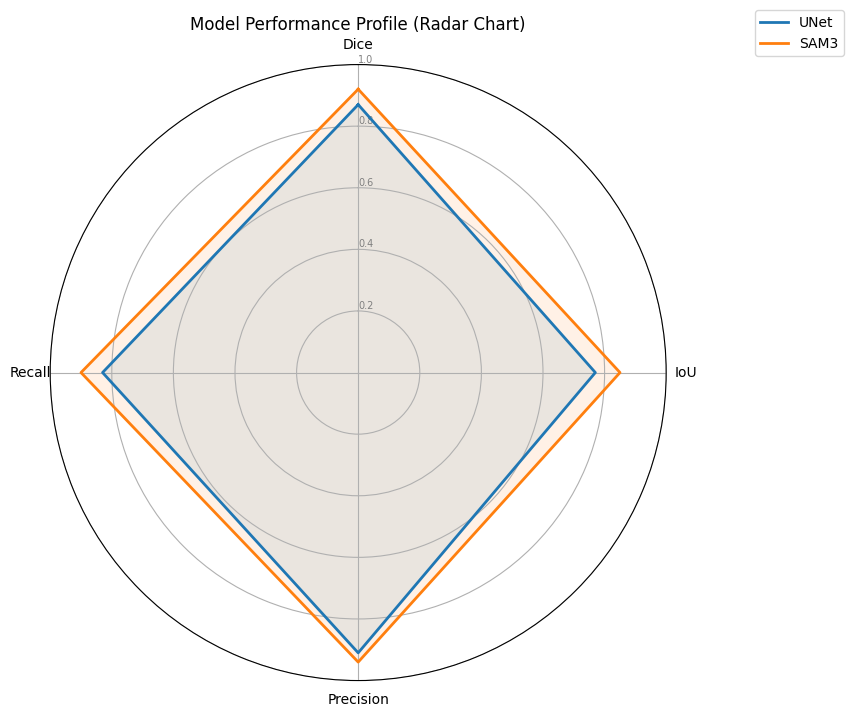

In [28]:
from monai_wg.plotting import plot_radar_chart

# The radar chart expects a DataFrame where each row is a model
radar_df = pd.DataFrame([
    {'Model': 'UNet',  'Dice': 0.87, 'IoU': 0.77, 'Precision': 0.91, 'Recall': 0.83},
    {'Model': 'SAM3',  'Dice': 0.92, 'IoU': 0.85, 'Precision': 0.94, 'Recall': 0.90},
])

plot_radar_chart(radar_df, metrics=['Dice', 'IoU', 'Precision', 'Recall'])

### 8.10 `plot_performance_vs_size` — IoU vs Object Size

Shows how segmentation quality varies with object size (pixel count). Small objects are typically harder to segment.

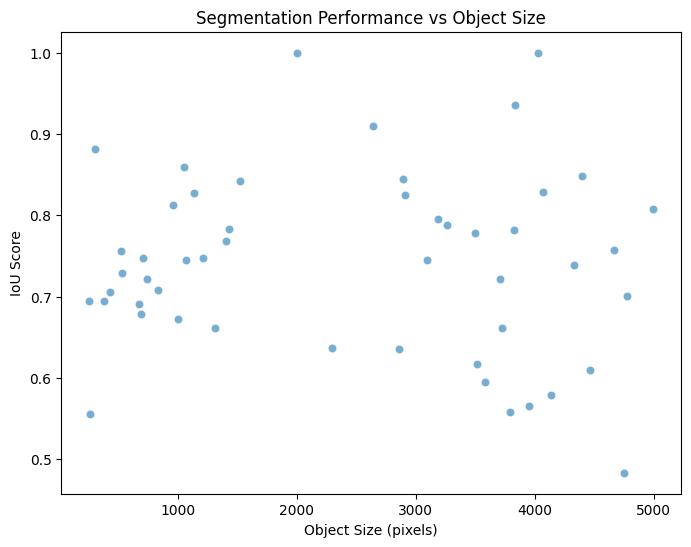

In [29]:
from monai_wg.plotting import plot_performance_vs_size

size_df = pd.DataFrame({
    'Size': np.random.randint(100, 5000, 50),
    'IoU':  np.clip(np.random.normal(0.75, 0.12, 50), 0, 1),
})

plot_performance_vs_size(size_df)

### 8.11 `plot_training_history` — Training vs Validation Curves

Plots standard training curves for loss and metrics over epochs.

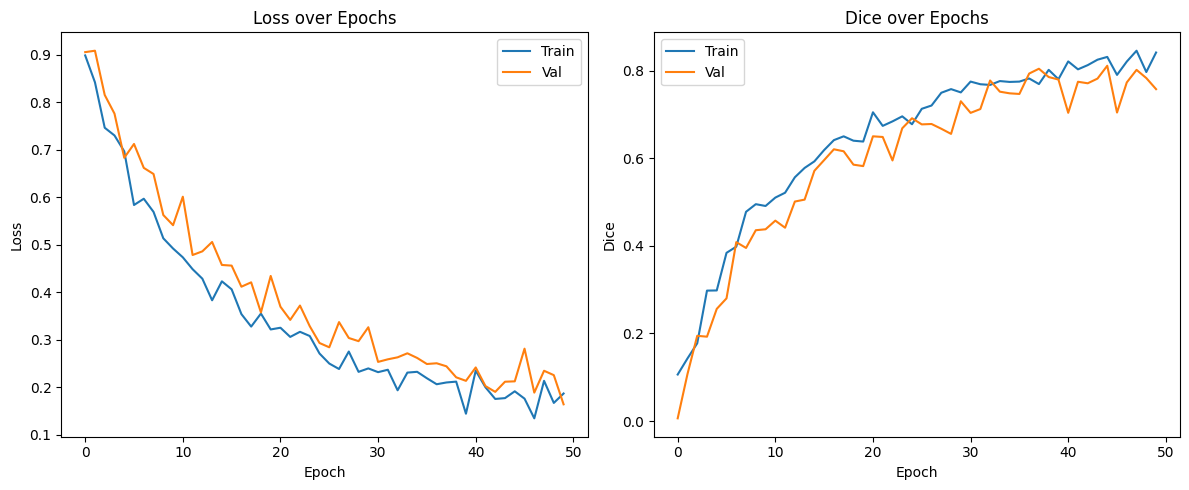

In [30]:
from monai_wg.plotting import plot_training_history

epochs = np.arange(1, 51)
history_df = pd.DataFrame({
    'train_Loss': 1.0 / (1 + 0.1 * epochs) + np.random.normal(0, 0.02, 50),
    'val_Loss':   1.0 / (1 + 0.08 * epochs) + np.random.normal(0, 0.03, 50),
    'train_Dice': 1 - 1.0 / (1 + 0.1 * epochs) + np.random.normal(0, 0.02, 50),
    'val_Dice':   1 - 1.0 / (1 + 0.08 * epochs) + np.random.normal(0, 0.03, 50),
})

plot_training_history(history_df, metrics=['Loss', 'Dice'])

### 8.12 `plot_summary_report` — All-in-One Dashboard

Generates a multi-panel summary with metric distributions, overlay visualization, and a bar chart — all in one figure.

f:\AI_ML_Notebooks\Monai-Ultra-Sound-WG\monai_wg\plotting.py:199: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x='Metric', y='Score', ax=ax1, palette='Set2')


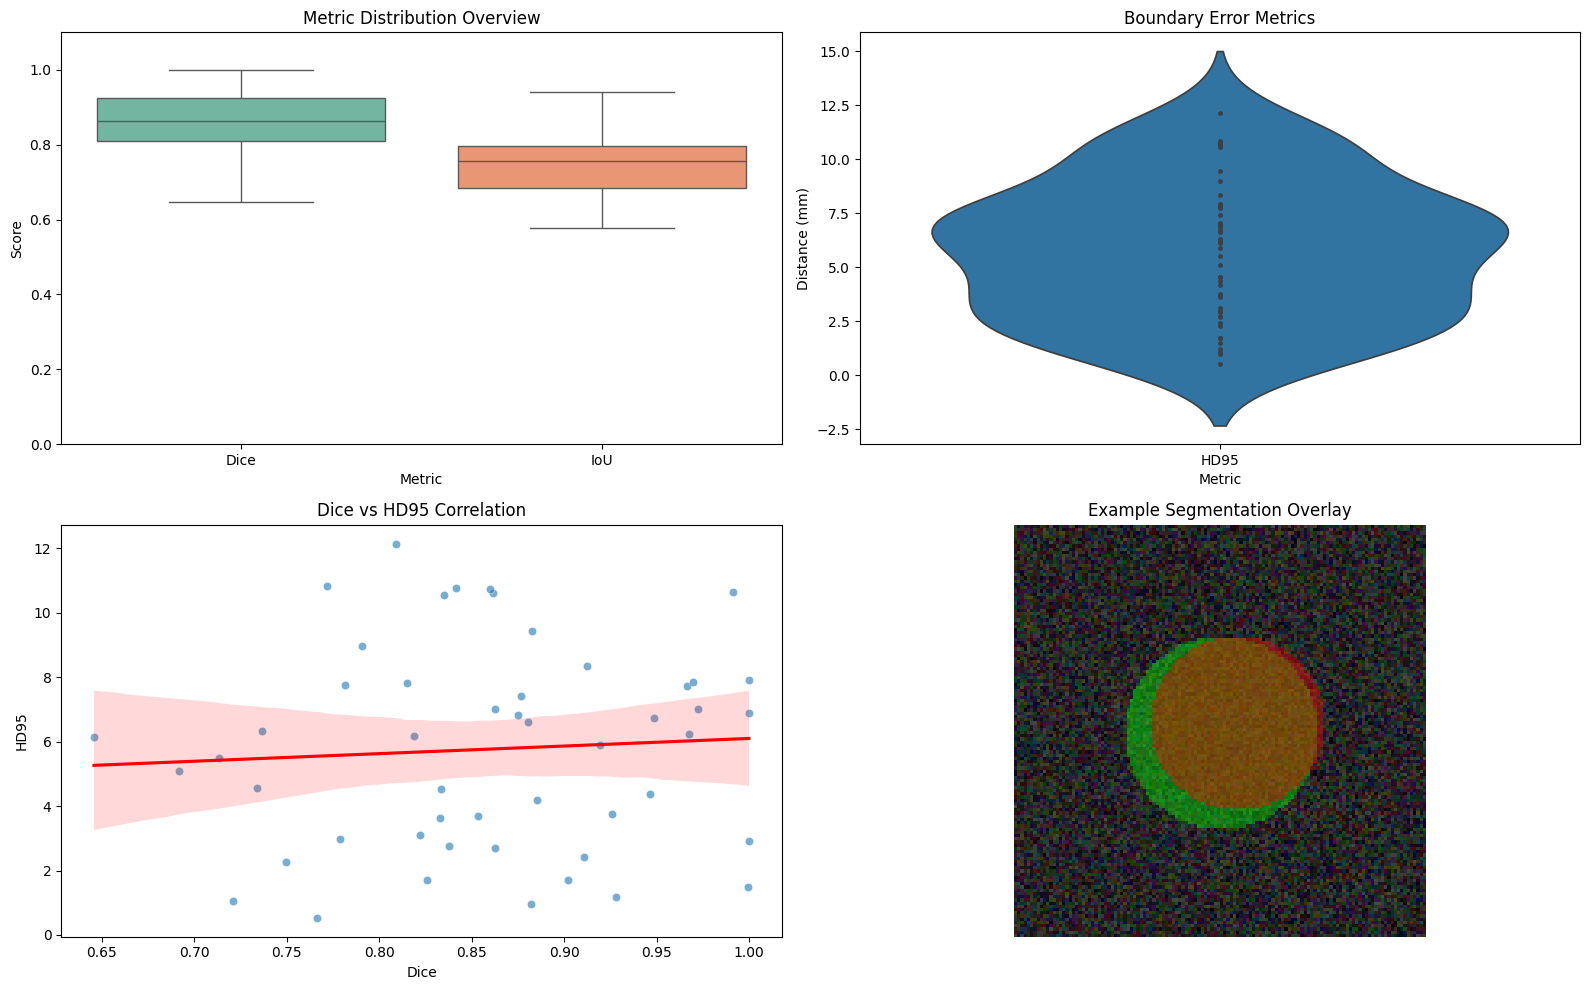

In [31]:
from monai_wg.plotting import plot_summary_report

plot_summary_report(
    metrics_df=sim_df,
    overlay_info={
        'image': dummy_img,
        'label': y_true_synth[0],
        'pred':  y_pred_synth[0],
    }
)

---
## 9. Post-Processing Pipeline

The `monai_wg.postprocessing` module provides a plug-and-play pipeline that chains common post-processing steps:

1. **Resize** to a target spatial size.
2. **Activation** (sigmoid / softmax) to convert logits → probabilities.
3. **Discretization** (threshold / argmax) to convert probabilities → binary masks.
4. **Cleanup** via `KeepLargestConnectedComponent` to remove small noisy regions.

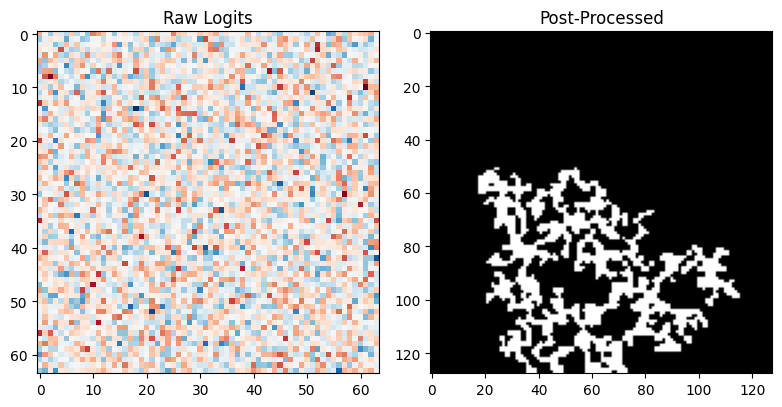

In [32]:
from monai_wg.postprocessing import PostProcessingPipeline, get_standard_postprocessing

# Simulate raw model logits (before sigmoid)
raw_logits = torch.randn(1, 1, 64, 64)  # (B, C, H, W)

# Standard pipeline: Sigmoid → Threshold(0.5) → Cleanup
pipeline = get_standard_postprocessing(target_size=(128, 128))
processed = pipeline(raw_logits)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(raw_logits[0, 0], cmap='RdBu'); axes[0].set_title('Raw Logits')
axes[1].imshow(processed[0, 0], cmap='gray'); axes[1].set_title('Post-Processed')
plt.tight_layout(); plt.show()

You can also customize each step individually:

In [33]:
custom_pipeline = PostProcessingPipeline(
    target_spatial_size=(256, 256),
    resize_mode='nearest',        # Use nearest-neighbor instead of bilinear
    activation='sigmoid',
    discretization='threshold',
    discretization_threshold=0.3,  # Lower threshold → more aggressive segmentation
    cleanup=True,
    cleanup_labels=[1],
)
processed_custom = custom_pipeline(raw_logits)
print(f'Output shape: {processed_custom.shape}')

Output shape: torch.Size([1, 1, 256, 256])


## 10. Managing Experiments with `config.yaml`

For repeatable research, it's best to manage paths, model hyperparameters, and benchmark settings in a central `config.yaml` file. 

Here is how you can load and use the provided configuration within this environment:

```python
import yaml
from pathlib import Path

# Load Configuration
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Accessing parameters
device = config['model']['device']
output_dir = Path(config['paths']['output_dir'])

print(f"Active Device: {device}")
print(f"Results will be saved to: {output_dir}")
```

---
## 🎉 You're All Set!

You've now seen the complete `monai_wg` toolkit:

- **`monai_wg.metrics`** — Compute Dice, IoU, HD95, ASD, Precision, Recall in one call.
- **`monai_wg.plotting`** — 10+ publication-ready visualizations.
- **`monai_wg.postprocessing`** — Plug-and-play post-processing pipeline.
- **`config.yaml`** — Centralized experiment configuration.

For the full API reference, see the [README](monai_wg/README.md) inside the `monai_wg` directory.

Happy segmenting! 🧠🔬